# Travel Mode Choice in Victoria
## Analysis of Household and Individual Characteristics

This project uses VISTA 2023–2024 data to investigate associations between household demographics, individual characteristics, and travel mode for work and education journeys. KNN and decision tree models are compared using random sampling, stratified sampling, and a reduced feature set.

## 1. Setup and Data Loading 

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / "data" / "raw").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data" / "raw").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Cannot find data/raw. Run this notebook from the project root or src."
    )

SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_PATH = PROCESSED_DIR / "preprocessed.csv"

print("Project root:", PROJECT_ROOT)
print("Raw data folder:", DATA_DIR)

Project root: /Users/paige/Desktop/Victoria-travel-mode-analysis-
Raw data folder: /Users/paige/Desktop/Victoria-travel-mode-analysis-/data/raw


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from preprocessing_helpers import (
    mode_group,
    bike_ownership,
    clean_income_level,
    age_bin,
    emp_status_bin,
    private_veh_ownership,
    household_size_bin,
    region_bin,
    distance_bin,
)

from ml_helpers import crossValidate, evaluate

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import normalized_mutual_info_score

In [3]:
household_df = pd.read_csv(
    DATA_DIR / "household_vista_2023_2024.csv"
)

person_df = pd.read_csv(
    DATA_DIR / "person_vista_2023_2024.csv"
)

edu_journey_df = pd.read_csv(
    DATA_DIR / "journey_to_education_vista_2023_2024.csv"
)

work_journey_df = pd.read_csv(
    DATA_DIR / "journey_to_work_vista_2023_2024.csv"
)

## 2. Data Preprocessing and Integration

Construct household, individual, and journey features, merge the datasets, and export the processed data.

In [4]:
households = clean_income_level(household_df)
households = private_veh_ownership(households, person_df)
households = bike_ownership(households)
households = household_size_bin(households, size_col="hhsize")
households = region_bin(
    households,
    region_col="homesubregion_ASGS",
)

household_keep = [
    "hhid",
    "income_level",
    "hhsize_binned",
    "bike_ownership",
    "car_ownership",
    "region_binned",
]

household_demographics = households[household_keep].copy()

In [5]:
individual = age_bin(person_df, age_col="agegroup")
individual = emp_status_bin(
    individual,
    mainact_column="mainact",
)

individual_keep = [
    "persid",
    "hhid",
    "age_binned",
    "employment_binned",
]

individual_characteristics = individual[individual_keep].copy()

In [6]:
edu_journey_df["journey_distance"] = pd.to_numeric(
    edu_journey_df["journey_distance"],
    errors="coerce",
)

work_journey_df["journey_distance"] = pd.to_numeric(
    work_journey_df["journey_distance"],
    errors="coerce",
)

negative_rows = work_journey_df[
    work_journey_df["journey_distance"] <= 0
]

work_journey_df = work_journey_df.drop(negative_rows.index)

edu_journey_df = distance_bin(
    edu_journey_df,
    "journey_distance",
)

work_journey_df = distance_bin(
    work_journey_df,
    "journey_distance",
)

journeys_edu = mode_group(
    edu_journey_df,
    mode_col="main_journey_mode",
)

journeys_work = mode_group(
    work_journey_df,
    mode_col="main_journey_mode",
)

journey_edu_keep = [
    "hhid",
    "persid",
    "main_journey_mode",
    "mode_group",
    "distance_group",
]

journey_work_keep = [
    "hhid",
    "persid",
    "main_journey_mode",
    "mode_group",
    "distance_group",
]

journeys_edu_final = journeys_edu[journey_edu_keep].copy()
journeys_work_final = journeys_work[journey_work_keep].copy()

In [7]:
journeys_final = pd.concat(
    [journeys_edu_final, journeys_work_final],
    axis=0,
    ignore_index=True,
)

final = (
    journeys_final
    .merge(
        individual_characteristics,
        on=["hhid", "persid"],
        how="left",
        validate="many_to_one",
    )
    .merge(
        household_demographics,
        on=["hhid"],
        how="left",
        validate="many_to_one",
    )
)

ordered_cols = [
    "hhid",
    "persid",
    "main_journey_mode",
    "mode_group",
    "distance_group",
    "income_level",
    "hhsize_binned",
    "bike_ownership",
    "car_ownership",
    "region_binned",
    "age_binned",
    "employment_binned",
]

final = final[ordered_cols]
final = final.loc[~final["mode_group"].isna()]

final.to_csv(PROCESSED_PATH, index=False)

## 3. Feature Association

Use normalised mutual information (NMI) to assess associations between predictors and travel mode.

In [8]:
dataset = pd.read_csv(PROCESSED_PATH)

features = [
    "income_level",
    "hhsize_binned",
    "bike_ownership",
    "car_ownership",
    "region_binned",
    "age_binned",
    "employment_binned",
    "distance_group",
]

predictor = dataset[features]
outcome = dataset["mode_group"]

nmi = []

for column in predictor:
    score = normalized_mutual_info_score(
        predictor[column],
        outcome,
        average_method="min",
    )
    nmi.append(score)

pd.DataFrame(
    {"NMI": nmi},
    index=features,
).rename_axis("Features")

,NMI
Features,
income_level,0.017114
hhsize_binned,0.004666
bike_ownership,0.004841
car_ownership,0.226703
region_binned,0.043727
age_binned,0.061093
employment_binned,0.027703
distance_group,0.024511


## 4. Encoding and Data Splitting

Prepare three experiments: random sampling, stratified sampling, and stratified sampling with household size and bicycle ownership removed.

In [9]:
encoder = OneHotEncoder()
X = encoder.fit_transform(predictor)

y = np.asarray(outcome)

# Random split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=20008,
)

# Stratified split
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X,
    y,
    train_size=0.8,
    stratify=y,
    random_state=1001,
)

# Reduced feature set
X_subset = dataset[
    [
        "income_level",
        "car_ownership",
        "region_binned",
        "age_binned",
        "employment_binned",
        "distance_group",
    ]
]

X_subset = encoder.fit_transform(X_subset)

(
    X_train_subset,
    X_test_subset,
    y_train_subset,
    y_test_subset,
) = train_test_split(
    X_subset,
    y,
    train_size=0.8,
    stratify=y,
    random_state=1003,
)

## 5. K-Nearest Neighbours

Evaluate an initial model with five neighbours, tune the neighbour count using five-fold cross-validation, and evaluate the selected model for each experiment.

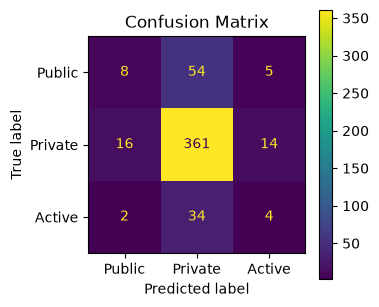

Accuracy: 0.749
Precision: 0.687
Recall: 0.749
F1: 0.708
k=2 Accuracy: 0.706
k=3 Accuracy: 0.708
k=4 Accuracy: 0.73
k=5 Accuracy: 0.73
k=6 Accuracy: 0.74
k=7 Accuracy: 0.742
k=8 Accuracy: 0.742
k=9 Accuracy: 0.746
k=10 Accuracy: 0.745
k=11 Accuracy: 0.742
k=12 Accuracy: 0.744
k=13 Accuracy: 0.746
k=14 Accuracy: 0.744
k=15 Accuracy: 0.745


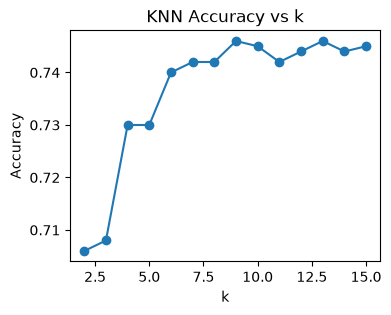

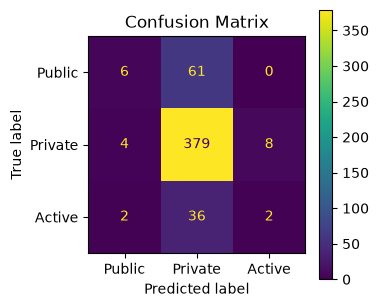

Accuracy: 0.777
Precision: 0.708
Recall: 0.777
F1: 0.713


In [10]:
# KNN: random sampling
knn = KNN(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
evaluate(y_test, y_pred)

accuracies = []

for k in range(2, 16):
    knn = KNN(n_neighbors=k)

    avgAcc = crossValidate(X_train, y_train, knn)
    accuracies.append(avgAcc)

    print(f"k={k} Accuracy: {avgAcc}")

depths = list(range(2, 16))
accs = list(accuracies)

plt.figure(figsize=(4, 3))
plt.plot(depths, accs, marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.show()

k = np.argmax(accuracies) + 2

knn = KNN(n_neighbors=k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
evaluate(y_test, y_pred)

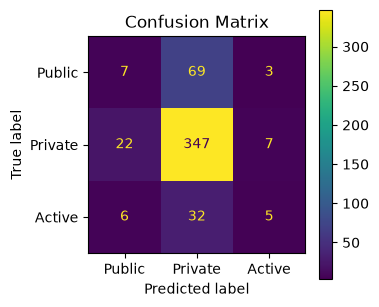

Accuracy: 0.721
Precision: 0.645
Recall: 0.721
F1: 0.67
k=2 Accuracy: 0.703
k=3 Accuracy: 0.708
k=4 Accuracy: 0.721
k=5 Accuracy: 0.733
k=6 Accuracy: 0.737
k=7 Accuracy: 0.744
k=8 Accuracy: 0.744
k=9 Accuracy: 0.752
k=10 Accuracy: 0.751
k=11 Accuracy: 0.751
k=12 Accuracy: 0.756
k=13 Accuracy: 0.76
k=14 Accuracy: 0.758
k=15 Accuracy: 0.759
k=16 Accuracy: 0.759
k=17 Accuracy: 0.759
k=18 Accuracy: 0.76
k=19 Accuracy: 0.758
k=20 Accuracy: 0.76


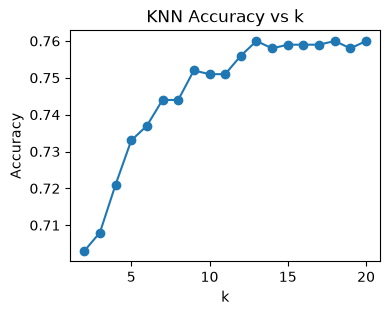

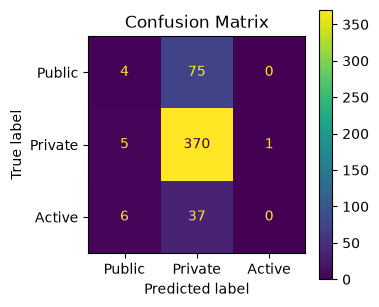

Accuracy: 0.751
Precision: 0.622
Recall: 0.751
F1: 0.665


In [11]:
# KNN: stratified sampling
knn = KNN(n_neighbors=5)
knn.fit(X_train_new, y_train_new)

y_pred_new = knn.predict(X_test_new)
evaluate(y_test_new, y_pred_new)

accuracies = []

for k in range(2, 21):
    knn = KNN(n_neighbors=k)

    avgAcc = crossValidate(X_train_new, y_train_new, knn)
    accuracies.append(avgAcc)

    print(f"k={k} Accuracy: {avgAcc}")

depths = list(range(2, 21))
accs = list(accuracies)

plt.figure(figsize=(4, 3))
plt.plot(depths, accs, marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.show()

k = np.argmax(accuracies) + 2

knn = KNN(n_neighbors=k)
knn.fit(X_train_new, y_train_new)

y_pred = knn.predict(X_test_new)
evaluate(y_test_new, y_pred)

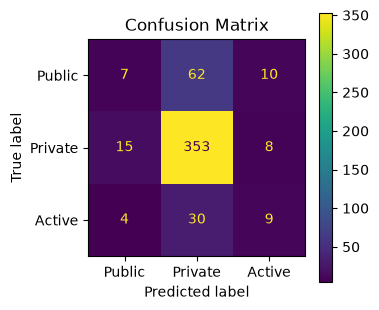

Accuracy: 0.741
Precision: 0.67
Recall: 0.741
F1: 0.693
k=2 Accuracy: 0.688
k=3 Accuracy: 0.719
k=4 Accuracy: 0.728
k=5 Accuracy: 0.739
k=6 Accuracy: 0.749
k=7 Accuracy: 0.753
k=8 Accuracy: 0.749
k=9 Accuracy: 0.755
k=10 Accuracy: 0.753
k=11 Accuracy: 0.759
k=12 Accuracy: 0.761
k=13 Accuracy: 0.761
k=14 Accuracy: 0.762
k=15 Accuracy: 0.761
k=16 Accuracy: 0.763
k=17 Accuracy: 0.762
k=18 Accuracy: 0.762
k=19 Accuracy: 0.76
k=20 Accuracy: 0.759
k=21 Accuracy: 0.76
k=22 Accuracy: 0.76
k=23 Accuracy: 0.759
k=24 Accuracy: 0.76
k=25 Accuracy: 0.759
k=26 Accuracy: 0.759
k=27 Accuracy: 0.758
k=28 Accuracy: 0.759
k=29 Accuracy: 0.757
k=30 Accuracy: 0.76
k=31 Accuracy: 0.759
k=32 Accuracy: 0.758
k=33 Accuracy: 0.758


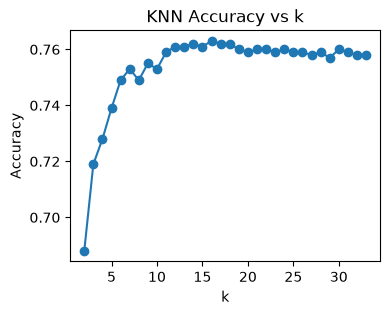

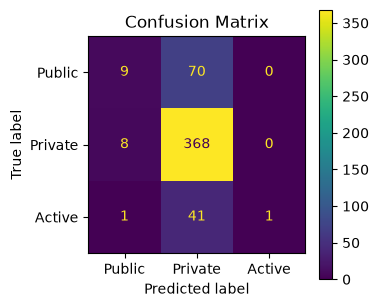

Accuracy: 0.759
Precision: 0.746
Recall: 0.759
F1: 0.683


In [12]:
# KNN: stratified sampling with reduced features
knn = KNN(n_neighbors=5)
knn.fit(X_train_subset, y_train_subset)

y_pred_subset = knn.predict(X_test_subset)
evaluate(y_test_subset, y_pred_subset)

accuracies = []

for k in range(2, 34):
    knn = KNN(n_neighbors=k)

    avgAcc = crossValidate(
        X_train_subset,
        y_train_subset,
        knn,
    )
    accuracies.append(avgAcc)

    print(f"k={k} Accuracy: {avgAcc}")

depths = list(range(2, 34))
accs = list(accuracies)

plt.figure(figsize=(4, 3))
plt.plot(depths, accs, marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.show()

k = np.argmax(accuracies) + 2

knn = KNN(n_neighbors=k)
knn.fit(X_train_subset, y_train_subset)

y_pred = knn.predict(X_test_subset)
evaluate(y_test_subset, y_pred)

## 6. Decision Tree Classification

Evaluate an initial tree with a maximum depth of three, tune tree depth using five-fold cross-validation, and evaluate the selected model for each experiment.

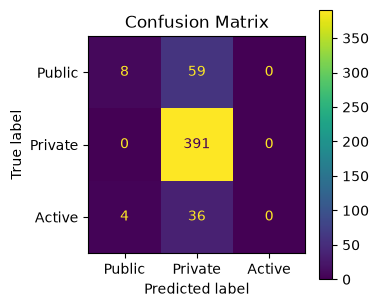

Accuracy: 0.801
Precision: 0.721
Recall: 0.801
F1: 0.727
max_depth=2, Accuracy=0.7540
max_depth=3, Accuracy=0.7550
max_depth=4, Accuracy=0.7540
max_depth=5, Accuracy=0.7510
max_depth=None, Accuracy=0.7000


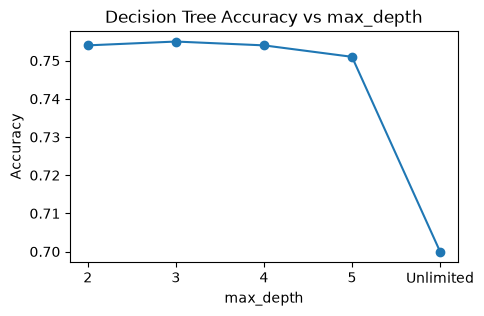

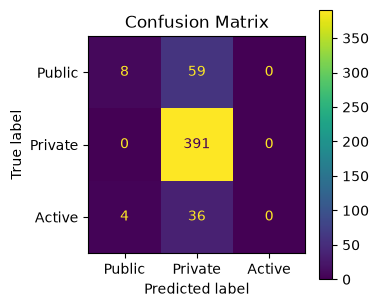

Accuracy: 0.801
Precision: 0.721
Recall: 0.801
F1: 0.727


In [13]:
# Decision tree: random sampling
dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    criterion="entropy",
)

dt.fit(X_train, y_train)

y_pred_DT = dt.predict(X_test)
evaluate(y_test, y_pred_DT)

depth_values = [2, 3, 4, 5, None]
results = []

for d in depth_values:
    dt = DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        criterion="entropy",
    )

    acc = crossValidate(X_train, y_train, dt)
    results.append(acc)

    print(f"max_depth={d}, Accuracy={acc:.4f}")

# Display all candidates, including unlimited depth.
depth_labels = [
    str(d) if d is not None else "Unlimited"
    for d in depth_values
]

plt.figure(figsize=(5, 3))
plt.plot(depth_labels, results, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs max_depth")
plt.show()

# Corrected: select the actual tested depth.
d = depth_values[np.argmax(results)]

dt = DecisionTreeClassifier(
    max_depth=d,
    random_state=42,
    criterion="entropy",
)

dt.fit(X_train, y_train)

y_pred_DT = dt.predict(X_test)
evaluate(y_test, y_pred_DT)

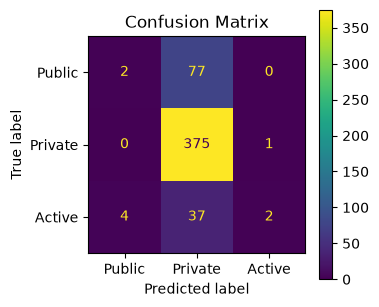

Accuracy: 0.761
Precision: 0.689
Recall: 0.761
F1: 0.67
max_depth=2, Accuracy=0.7670
max_depth=3, Accuracy=0.7670
max_depth=4, Accuracy=0.7680
max_depth=5, Accuracy=0.7640
max_depth=None, Accuracy=0.6930


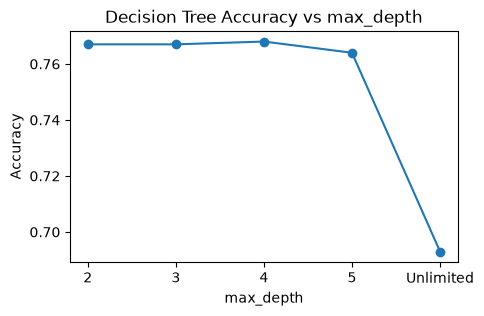

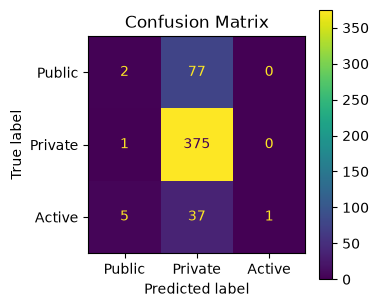

Accuracy: 0.759
Precision: 0.705
Recall: 0.759
F1: 0.666


In [14]:
# Decision tree: stratified sampling
dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    criterion="entropy",
)

dt.fit(X_train_new, y_train_new)

y_pred_DT_new = dt.predict(X_test_new)
evaluate(y_test_new, y_pred_DT_new)

depth_values = [2, 3, 4, 5, None]
results = []

for d in depth_values:
    dt = DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        criterion="entropy",
    )

    acc = crossValidate(X_train_new, y_train_new, dt)
    results.append(acc)

    print(f"max_depth={d}, Accuracy={acc:.4f}")

depth_labels = [
    str(d) if d is not None else "Unlimited"
    for d in depth_values
]

plt.figure(figsize=(5, 3))
plt.plot(depth_labels, results, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs max_depth")
plt.show()

# Corrected depth selection
d = depth_values[np.argmax(results)]

dt = DecisionTreeClassifier(
    max_depth=d,
    random_state=42,
    criterion="entropy",
)

dt.fit(X_train_new, y_train_new)

y_pred_DT_new = dt.predict(X_test_new)
evaluate(y_test_new, y_pred_DT_new)

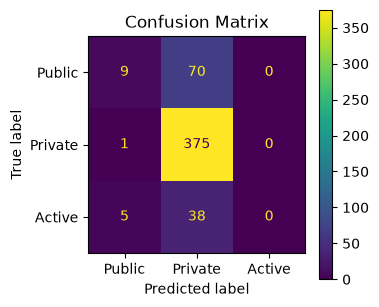

Accuracy: 0.771
Precision: 0.681
Recall: 0.771
F1: 0.69
max_depth=2, Accuracy=0.7610
max_depth=3, Accuracy=0.7620
max_depth=4, Accuracy=0.7600
max_depth=5, Accuracy=0.7610
max_depth=None, Accuracy=0.7320


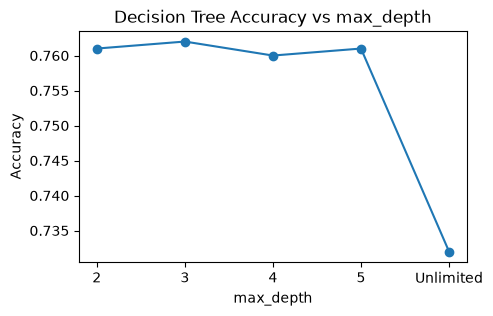

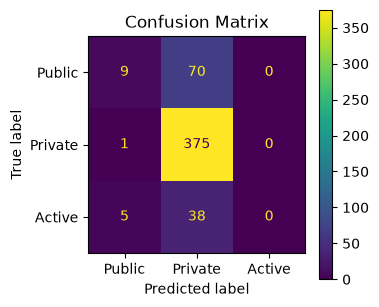

Accuracy: 0.771
Precision: 0.681
Recall: 0.771
F1: 0.69


In [15]:
# Decision tree: stratified sampling with reduced features
dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42,
    criterion="entropy",
)

dt.fit(X_train_subset, y_train_subset)

y_pred_DT_subset = dt.predict(X_test_subset)
evaluate(y_test_subset, y_pred_DT_subset)

depth_values = [2, 3, 4, 5, None]
results = []

for d in depth_values:
    dt = DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        criterion="entropy",
    )

    acc = crossValidate(
        X_train_subset,
        y_train_subset,
        dt,
    )
    results.append(acc)

    print(f"max_depth={d}, Accuracy={acc:.4f}")

depth_labels = [
    str(d) if d is not None else "Unlimited"
    for d in depth_values
]

plt.figure(figsize=(5, 3))
plt.plot(depth_labels, results, marker="o")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs max_depth")
plt.show()

# Corrected depth selection
d = depth_values[np.argmax(results)]

dt = DecisionTreeClassifier(
    max_depth=d,
    random_state=42,
    criterion="entropy",
)

dt.fit(X_train_subset, y_train_subset)

y_pred_DT_subset = dt.predict(X_test_subset)
evaluate(y_test_subset, y_pred_DT_subset)

## 7. Implementation Notes and Limitations

The original preprocessing rules, feature sets, random seeds, model configurations, tuning ranges, cross-validation helper, and evaluation helper are retained.

Changes are limited to notebook path setup, renamed helper imports, the processed CSV filename, removal of unused imports, corrected decision tree depth selection, and displaying unlimited depth in tuning plots.

The original evaluation limitations remain: encoding and NMI are performed before splitting; experiments use different test sets; and journeys from the same person or household may appear in both training and test data. Missing-income handling and distance-bin definitions are also retained from the original helpers.

The tree-depth correction may change results if unlimited depth is selected. Outputs should be regenerated before comparing them with the submitted report.